In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv("museums.csv")

/var/folders/6r/zm3djk_x3_15kv9nmd037_480000gn/T/ipykernel_14068/3263594445.py:1: DtypeWarning: Columns (0: Zip Code (Administrative Location), 1: Phone Number, 2: Employer ID Number) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("museums.csv")


In [3]:
df.head()
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33072 entries, 0 to 33071
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Museum ID                                 33072 non-null  int64  
 1   Museum Name                               33072 non-null  str    
 2   Legal Name                                33072 non-null  str    
 3   Alternate Name                            1927 non-null   str    
 4   Museum Type                               33072 non-null  str    
 5   Institution Name                          2749 non-null   str    
 6   Street Address (Administrative Location)  33062 non-null  str    
 7   City (Administrative Location)            33072 non-null  str    
 8   State (Administrative Location)           33072 non-null  str    
 9   Zip Code (Administrative Location)        33072 non-null  object 
 10  Street Address (Physical Location)        921

In [4]:
df = df.drop_duplicates()
df.isnull().sum()

Museum ID                                       0
Museum Name                                     0
Legal Name                                      0
Alternate Name                              31145
Museum Type                                     0
Institution Name                            30323
Street Address (Administrative Location)       10
City (Administrative Location)                  0
State (Administrative Location)                 0
Zip Code (Administrative Location)              0
Street Address (Physical Location)          23856
City (Physical Location)                    23849
State (Physical Location)                   23849
Zip Code (Physical Location)                23851
Phone Number                                10140
Latitude                                       65
Longitude                                      65
Locale Code (NCES)                             77
County Code (FIPS)                           2536
State Code (FIPS)                               1


In [ ]:
## Questions about the data set

Within in the new jupyter notebook answer the following questions.

- Which city or state has the most museums per capita? 
- Which city or state has the least museums per capita? 
- How many zoos or aquariums exist in the United States?
- How many zoos?
- How many aquariums?
- What museum or related organization had the highest revenue last year? 
- How does the composition of museum types differ across the country?
- For each type of museum, statistical measure on revenue and income?

## Viz

Create a visualization of some aspect of the data set. Perhaps a chart showing museums/zoos/aquariums per state...

Show a chart/plot/visualization which shows the distribution of money across the data set.

In [6]:
df.columns.tolist()

['Museum ID',
 'Museum Name',
 'Legal Name',
 'Alternate Name',
 'Museum Type',
 'Institution Name',
 'Street Address (Administrative Location)',
 'City (Administrative Location)',
 'State (Administrative Location)',
 'Zip Code (Administrative Location)',
 'Street Address (Physical Location)',
 'City (Physical Location)',
 'State (Physical Location)',
 'Zip Code (Physical Location)',
 'Phone Number',
 'Latitude',
 'Longitude',
 'Locale Code (NCES)',
 'County Code (FIPS)',
 'State Code (FIPS)',
 'Region Code (AAM)',
 'Employer ID Number',
 'Tax Period',
 'Income',
 'Revenue']

In [ ]:
- Which city or state has the least museums per capita? DE, dix hills, dividing creek, district olathe, douglson, lomita
- Which city or state has the most museums per capita? CA, New York

In [7]:
state_counts = df.groupby('State (Administrative Location)').size().sort_values(ascending=False)

state_counts.head()

State (Administrative Location)
CA    2670
NY    2239
TX    1886
PA    1653
OH    1363
dtype: int64

In [9]:
state_counts.sort_values().head()

State (Administrative Location)
DE    132
AK    162
UT    170
NV    174
HI    176
dtype: int64

In [8]:
city_counts = df.groupby('City (Administrative Location)').size().sort_values(ascending=False)

city_counts.head()

City (Administrative Location)
NEW YORK        297
WASHINGTON      228
CHICAGO         194
PHILADELPHIA    182
LOS ANGELES     162
dtype: int64

In [10]:
city_counts.sort_values().head()

City (Administrative Location)
LOMITA             1
DOUGLASTON         1
DISTRICT OLATHE    1
DIVIDING CREEK     1
DIX HILLS          1
dtype: int64

In [11]:
df['Museum Type'].unique()

<StringArray>
[                               'HISTORY MUSEUM',
 'ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER',
    'SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM',
                         'HISTORIC PRESERVATION',
                                'GENERAL MUSEUM',
       'ZOO, AQUARIUM, OR WILDLIFE CONSERVATION',
                                    'ART MUSEUM',
                             'CHILDREN'S MUSEUM',
                        'NATURAL HISTORY MUSEUM']
Length: 9, dtype: str

In [ ]:
- How many zoos or aquariums exist in the United States?

In [12]:
zoos_aquariums = df[
    df['Museum Type'].str.contains(
        'Zoo|Aquarium',
        case=False,
        na=False
    )
]

len(zoos_aquariums)

564

In [18]:
df['Museum Type'].value_counts()

Museum Type
HISTORIC PRESERVATION                            14861
GENERAL MUSEUM                                    8699
ART MUSEUM                                        3241
HISTORY MUSEUM                                    2284
ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER     1484
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM        1081
ZOO, AQUARIUM, OR WILDLIFE CONSERVATION            564
CHILDREN'S MUSEUM                                  512
NATURAL HISTORY MUSEUM                             346
Name: count, dtype: int64

In [19]:
df['Museum Type'].unique()

<StringArray>
[                               'HISTORY MUSEUM',
 'ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER',
    'SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM',
                         'HISTORIC PRESERVATION',
                                'GENERAL MUSEUM',
       'ZOO, AQUARIUM, OR WILDLIFE CONSERVATION',
                                    'ART MUSEUM',
                             'CHILDREN'S MUSEUM',
                        'NATURAL HISTORY MUSEUM']
Length: 9, dtype: str

In [ ]:
- How many zoos?

In [20]:
zoos = df[
    (df['Museum Type'] == 'ZOO, AQUARIUM, OR WILDLIFE CONSERVATION') &
    (df['Museum Name'].str.contains('Zoo', case=False, na=False))
]

len(zoos)

259

In [ ]:
- How many aquariums? The dataset does not provide a separate category for zoos. Zoos are grouped together with aquariums and wildlife conservation organizations.


In [24]:
aquariums = df[
    (df['Museum Type'] == 'ZOO, AQUARIUM, OR WILDLIFE CONSERVATION') &
    (df['Museum Name'].str.contains('Aquarium', case=False, na=False))
]

len(aquariums)
zoos[['Museum Name', 'Museum Type']].head(20)

,Museum Name,Museum Type
19,ALASKA ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
207,ALABAMA ZOOLOGICAL SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
254,BIRMINGHAM ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
475,MOBILE ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
478,MONTGOMERY AREA ZOOLOGICAL SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
709,CROSSETT ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
798,LITTLE ROCK ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
799,LITTLE ROCK ZOOLOGICAL GARDENS,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
995,ARIZONA ZOOLOGICAL SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
1240,PHOENIX ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"


In [25]:
conservations = df[
    (df['Museum Type'] == 'ZOO, AQUARIUM, OR WILDLIFE CONSERVATION') &
    (df['Museum Name'].str.contains('Conservation', case=False, na=False))
]

len(conservations)
aquariums[['Museum Name', 'Museum Type']].head(20)

,Museum Name,Museum Type
1313,SONORAN SEA AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
1498,AQUARIUM OF THE BAY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
1499,AQUARIUM OF THE PACIFIC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
1675,CABRILLO MARINE AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
1806,CENTRAL COAST AQUARIUM SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
2734,MARINE AQUARIUM SOCIETY OF LOS ANGELES COUNTY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
2738,MARINE SCIENCE DEPARTMENT PUBLIC AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
2840,MONTEREY BAY AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
3463,SAN DIEGO MARINE AQUARIUM SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
3482,SAN FRANCISCO AQUARIUM SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"


In [ ]:
Which Organization Had the Highest Revenue?

In [26]:
df.sort_values(
    'Revenue',
    ascending=False
)[
    ['Museum Name', 'Revenue']
].head(1)

,Museum Name,Revenue
12229,HARVARD UNIVERSITY MINERALOGICAL AND GEOLOGICA...,5.840349e+09


In [ ]:
Museum Type Composition Across the Country


In [27]:
museum_types = df.groupby(
    'Museum Type'
).size().sort_values(ascending=False)

museum_types

Museum Type
HISTORIC PRESERVATION                            14861
GENERAL MUSEUM                                    8699
ART MUSEUM                                        3241
HISTORY MUSEUM                                    2284
ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER     1484
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM        1081
ZOO, AQUARIUM, OR WILDLIFE CONSERVATION            564
CHILDREN'S MUSEUM                                  512
NATURAL HISTORY MUSEUM                             346
dtype: int64

In [ ]:
Revenue Statistics by Museum Type


In [28]:
df.groupby('Museum Type')['Revenue'].agg([
    'count',
    'mean',
    'median',
    'min',
    'max',
    'std'
])

,count,mean,median,min,max,std
Museum Type,,,,,,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",742,7.787922e+07,150130.5,-1428.0,5.840349e+09,5.384317e+08
ART MUSEUM,1844,1.007874e+08,1503702.0,-106157.0,5.840349e+09,4.226339e+08
CHILDREN'S MUSEUM,325,1.355364e+06,304322.0,0.0,3.702075e+07,3.781062e+06
GENERAL MUSEUM,4029,2.740284e+07,25487.0,-2127393.0,5.840349e+09,3.146240e+08
HISTORIC PRESERVATION,12382,2.035602e+06,0.0,-83151.0,5.840349e+09,9.022186e+07
HISTORY MUSEUM,2029,9.402442e+06,32602.0,-567630.0,5.121523e+09,1.662101e+08
NATURAL HISTORY MUSEUM,235,8.549832e+07,113442.0,0.0,5.840349e+09,5.594769e+08
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,412,1.143093e+08,335123.0,-1723674.0,5.840349e+09,6.617205e+08
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",292,5.483602e+06,329603.5,0.0,1.210595e+08,1.405838e+07


In [ ]:
Income Statistics by Museum Type

In [29]:
df.groupby('Museum Type')['Income'].agg([
    'count',
    'mean',
    'median',
    'min',
    'max',
    'std'
])

,count,mean,median,min,max,std
Museum Type,,,,,,
"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",776,4.807208e+08,195949.5,0.0,8.318144e+10,5.360681e+09
ART MUSEUM,1906,3.223146e+08,1983371.5,0.0,8.318144e+10,3.483209e+09
CHILDREN'S MUSEUM,330,1.963783e+06,313211.5,0.0,1.040673e+08,8.789033e+06
GENERAL MUSEUM,4326,1.772695e+08,40630.5,0.0,8.318144e+10,3.584905e+09
HISTORIC PRESERVATION,12544,9.473739e+06,0.0,0.0,8.318144e+10,7.552944e+08
HISTORY MUSEUM,2114,1.696311e+07,42212.0,-923.0,1.065060e+10,3.391802e+08
NATURAL HISTORY MUSEUM,244,5.898461e+08,137854.0,0.0,8.318144e+10,5.642206e+09
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,419,9.561813e+08,387131.0,0.0,8.318144e+10,8.147354e+09
"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",302,6.452933e+06,337346.5,0.0,1.374917e+08,1.716023e+07


In [ ]:
Visualization — Museums Per State

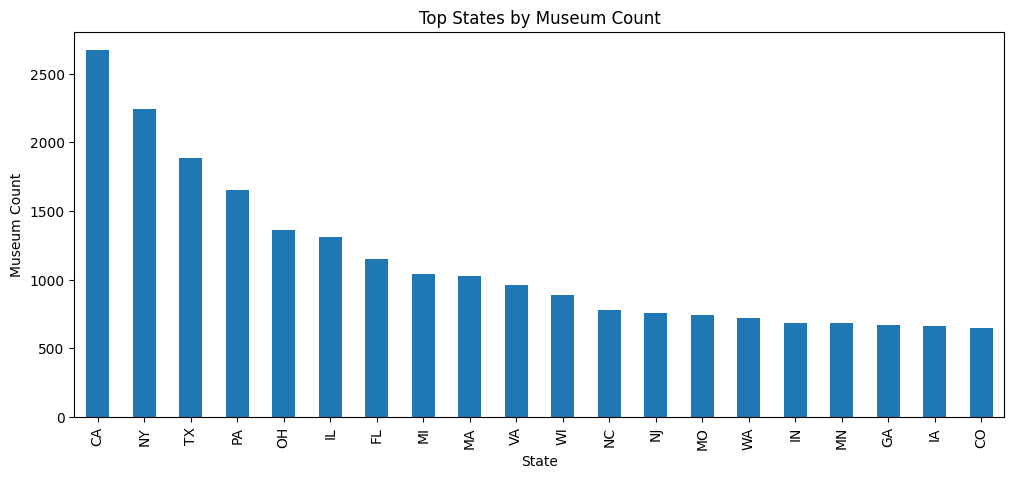

In [30]:
state_counts.head(20).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top States by Museum Count')
plt.xlabel('State')
plt.ylabel('Museum Count')

plt.show()

In [ ]:
Visualization — Revenue Distribution

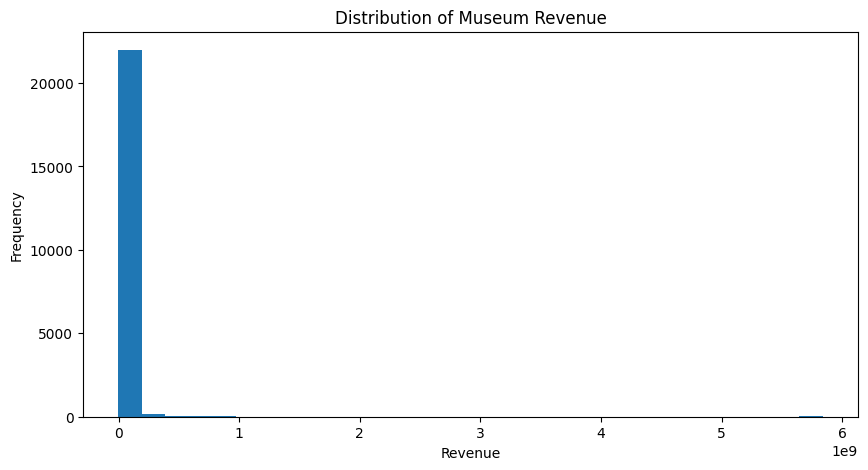

In [31]:
df['Revenue'].plot(
    kind='hist',
    bins=30,
    figsize=(10,5)
)

plt.title('Distribution of Museum Revenue')
plt.xlabel('Revenue')

plt.show()

In [ ]:
Museum Type Distribution

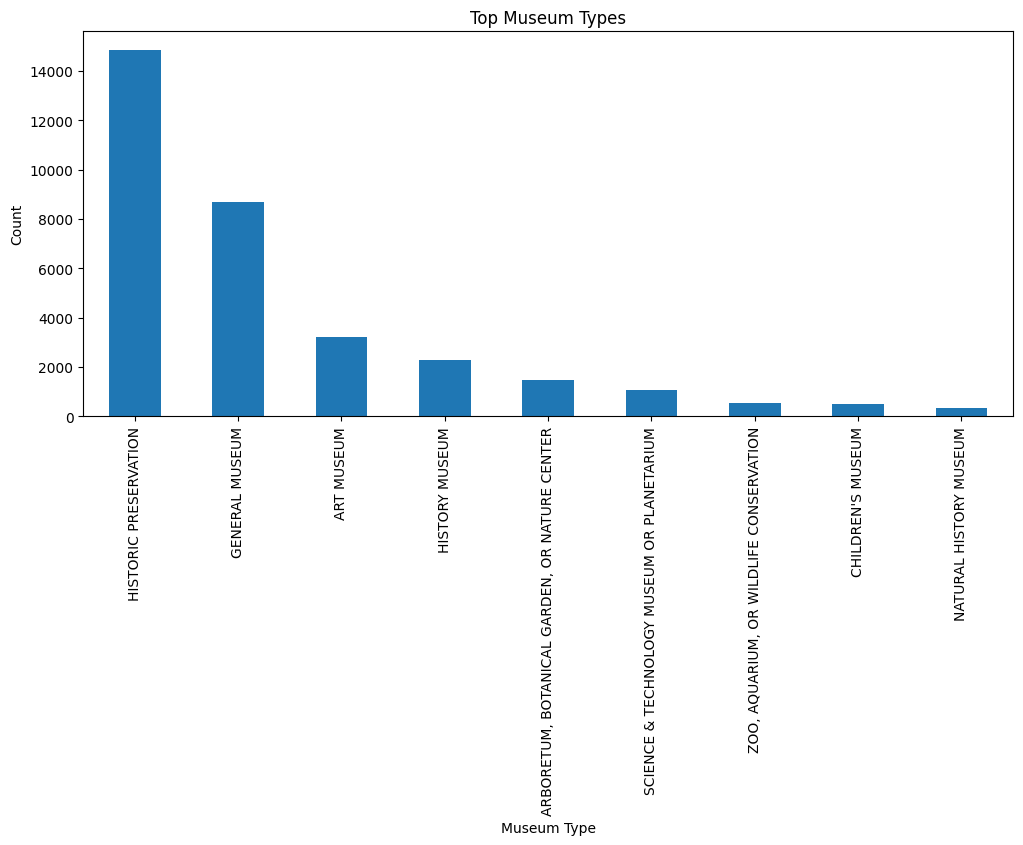

In [32]:
museum_types.head(10).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top Museum Types')
plt.xlabel('Museum Type')
plt.ylabel('Count')

plt.show()

In [ ]:
This project analyzed museum, zoo, and aquarium data using Pandas and Matplotlib. The dataset revealed differences in museum distribution across cities and states, as well as significant variation in revenue and income among museum types.

The analysis demonstrated how grouping, filtering, aggregation, and visualization techniques can be used to answer real-world questions using structured datasets. Data cleaning and inspection were important steps before performing analysis and creating visualizations.

The dataset grouped zoos, aquariums, and wildlife conservation organizations into a single category. Estimated zoo and aquarium counts were generated using keywords found in museum names, so those estimates may not represent exact totals.

Overall, this project strengthened skills in data analysis, visualization, DataFrame manipulation, and interpreting trends from large datasets.